## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})
ACCENT = '#1a6cf5'   # primary chart color
WARM   = '#e8593c'   # contrast / highlight color

DATA_DIR ='/Users/adnan/Downloads/archive/'
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 2. Load All Tables
The Olist dataset has 8 CSV files. We load each one and immediately check its shape and a quick `.info()` to spot data types and nulls.

In [2]:
import os
print("Python is currently looking in:", os.getcwd())
print("-" * 30)
print("Files Python can see here:", os.listdir())

Python is currently looking in: /Users/adnan/Desktop/python coding/brazilian data set
------------------------------
Files Python can see here: ['fig_category_revenue.png', 'rfm.csv', 'fig_feature_importance.png', 'fig_time_patterns.png', '.DS_Store', 'archive', 'fig_roc_curves.png', '02_ml_churn_fixed.ipynb', 'fig_model_comparison.png', 'fig_purchase_frequency.png', 'feature_importance.csv', '01_eda.ipynb', 'models', 'fig_delivery_vs_review.png', 'model_predictions.csv', 'master.csv', 'fig_payments.png', 'fig_geo_revenue.png', 'app.py', 'fig_confusion_matrix.png', 'fig_category_map.png', 'fig_permutation_importance.png', 'fig_monthly_revenue.png', 'fig_rfm_segments.png', 'fig_review_distribution.png', '03_forecasting.ipynb']


In [3]:
# ── Load all 8 CSVs ───────────────────────────────────────────────────────────
orders         = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_orders_dataset.csv')
order_items    = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_order_payments_dataset.csv')
order_reviews  = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_order_reviews_dataset.csv')
customers      = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_customers_dataset.csv')
products       = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_products_dataset.csv')
sellers        = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/olist_sellers_dataset.csv')
product_names  = pd.read_csv('/Users/adnan/Desktop/python coding/brazilian data set/archive/product_category_name_translation.csv')

tables = {
    'orders': orders, 'order_items': order_items, 'order_payments': order_payments,
    'order_reviews': order_reviews, 'customers': customers,
    'products': products, 'sellers': sellers, 'product_names': product_names
}

print('=== Table shapes ===')
for name, df in tables.items():
    print(f'  {name:<20} {df.shape[0]:>7,} rows  ×  {df.shape[1]:>2} cols')

=== Table shapes ===
  orders                99,441 rows  ×   8 cols
  order_items          112,650 rows  ×   7 cols
  order_payments       103,886 rows  ×   5 cols
  order_reviews         99,224 rows  ×   7 cols
  customers             99,441 rows  ×   5 cols
  products              32,951 rows  ×   9 cols
  sellers                3,095 rows  ×   4 cols
  product_names             71 rows  ×   2 cols


In [4]:
# ── Quick null audit across all tables ────────────────────────────────────────
print('=== Null counts (columns with >0 nulls) ===')
for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n[{name}]')
        print(nulls.to_string())

=== Null counts (columns with >0 nulls) ===

[orders]
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

[order_reviews]
review_comment_title      87656
review_comment_message    58247

[products]
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2


---
## 3. Data Cleaning
Key decisions documented here — each one matters for analysis accuracy.

In [5]:
# ── 3.1  Parse all datetime columns ───────────────────────────────────────────
# Why: they load as strings; we need them as datetime for time-series analysis
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'], errors='coerce'
)

print('Datetime columns parsed ✓')

Datetime columns parsed ✓


In [6]:
# ── 3.2  Orders: keep only 'delivered' status for revenue analysis ─────────────
# Why: cancelled, unavailable orders should not count toward revenue KPIs
print('Order status breakdown:')
print(orders['order_status'].value_counts().to_string())

delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'\nDelivered orders: {len(delivered):,} ({len(delivered)/len(orders)*100:.1f}% of total)')

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Delivered orders: 96,478 (97.0% of total)


In [7]:
# ── 3.3  Translate product category names to English ──────────────────────────
products = products.merge(product_names, on='product_category_name', how='left')
products['category'] = products['product_category_name_english'].fillna('unknown')

# ── 3.4  Compute delivery time in days ────────────────────────────────────────
# Why: delivery time is a key driver of customer satisfaction (review score)
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

delivered['estimated_days'] = (
    delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']
).dt.days

# Positive = early, Negative = late
delivered['delivery_delta'] = delivered['estimated_days'] - delivered['delivery_days']

print('Derived columns added ✓')
print(delivered[['delivery_days', 'estimated_days', 'delivery_delta']].describe().round(1))

Derived columns added ✓
       delivery_days  estimated_days  delivery_delta
count        96470.0         96478.0         96470.0
mean            12.1            23.4            11.3
std              9.6             8.8            10.2
min              0.0             2.0          -189.0
25%              6.0            18.0             7.0
50%             10.0            23.0            12.0
75%             15.0            28.0            16.0
max            209.0           155.0           146.0


---
## 4. Build the Master DataFrame
One row per order-item, enriched with customer, product, payment, and review data.

In [8]:
# ── 4.1  Aggregate payments per order (some orders have multiple payment rows) ─
payments_agg = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

# ── 4.2  Aggregate reviews per order (keep the most recent review) ─────────────
reviews_clean = order_reviews.sort_values('review_answer_timestamp', ascending=False)
reviews_agg = reviews_clean.groupby('order_id').agg(
    review_score=('review_score', 'first')
).reset_index()

# ── 4.3  Build master table ────────────────────────────────────────────────────
master = (
    delivered
    .merge(order_items[['order_id','order_item_id','product_id','seller_id','price','freight_value']],
           on='order_id', how='left')
    .merge(customers[['customer_id','customer_unique_id','customer_state','customer_city']],
           on='customer_id', how='left')
    .merge(products[['product_id','category','product_weight_g']],
           on='product_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

# ── 4.4  Add time features ─────────────────────────────────────────────────────
master['year']        = master['order_purchase_timestamp'].dt.year
master['month']       = master['order_purchase_timestamp'].dt.month
master['month_label'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
master['weekday']     = master['order_purchase_timestamp'].dt.day_name()
master['hour']        = master['order_purchase_timestamp'].dt.hour

print(f'Master DataFrame: {master.shape[0]:,} rows × {master.shape[1]} columns')
master.head(3)

Master DataFrame: 110,197 rows × 30 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days,...,product_weight_g,total_payment,payment_installments,payment_type,review_score,year,month,month_label,weekday,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,...,500.0,38.71,1.0,voucher,4.0,2017,10,2017-10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,...,400.0,141.46,1.0,boleto,4.0,2018,7,2018-07,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,...,420.0,179.12,3.0,credit_card,5.0,2018,8,2018-08,Wednesday,8


In [9]:
# ── 4.5  Save cleaned master to disk ──────────────────────────────────────────
# This file is used by all subsequent notebooks + the Streamlit dashboard
master.to_csv(os.path.join(DATA_DIR,'master.csv'), index=False)
print('master.csv saved ✓')

master.csv saved ✓


---
## 5. Revenue Analysis

In [10]:
# ── 5.1  Top-level KPIs ────────────────────────────────────────────────────────
total_revenue     = master['price'].sum()
total_orders      = master['order_id'].nunique()
unique_customers  = master['customer_unique_id'].nunique()
avg_order_value   = master.groupby('order_id')['price'].sum().mean()
avg_review        = master['review_score'].mean()

print('=== TOP-LINE KPIs ===')
print(f'  Total Revenue          R$ {total_revenue:>12,.2f}')
print(f'  Total Orders           {total_orders:>12,}')
print(f'  Unique Customers       {unique_customers:>12,}')
print(f'  Avg Order Value        R$ {avg_order_value:>11,.2f}')
print(f'  Avg Review Score           {avg_review:>10.2f} / 5.0')

=== TOP-LINE KPIs ===
  Total Revenue          R$ 13,221,498.11
  Total Orders                 96,478
  Unique Customers             93,358
  Avg Order Value        R$      137.04
  Avg Review Score                 4.08 / 5.0


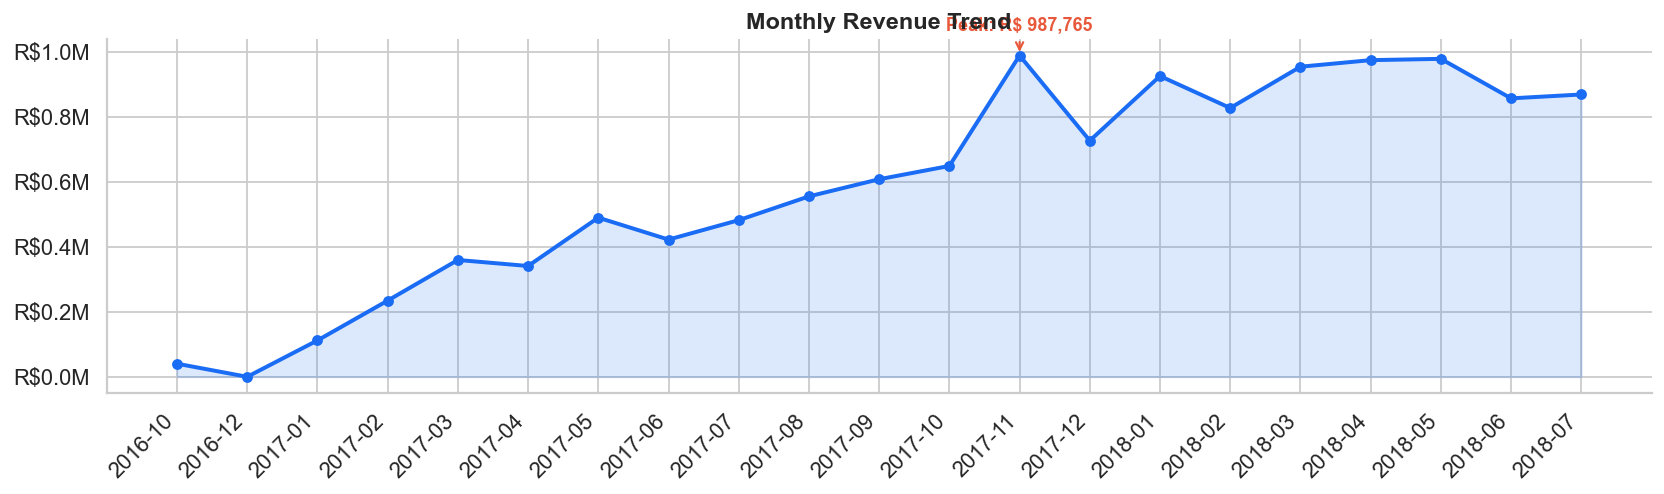


💡 Business insight: note the growth trajectory and any seasonal peaks (Nov = Black Friday?)


In [11]:
# ── 5.2  Monthly Revenue Trend ─────────────────────────────────────────────────
monthly_rev = (
    master.groupby('month_label')['price'].sum()
    .reset_index()
    .sort_values('month_label')
)
# Remove first and last months (often partial months in dataset)
monthly_rev = monthly_rev.iloc[1:-1]

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly_rev['month_label'], monthly_rev['price'],
                alpha=0.15, color=ACCENT)
ax.plot(monthly_rev['month_label'], monthly_rev['price'],
        color=ACCENT, linewidth=2.2, marker='o', markersize=5)

# Highlight peak month
peak_idx = monthly_rev['price'].idxmax()
ax.annotate(
    f"Peak: R$ {monthly_rev.loc[peak_idx,'price']:,.0f}",
    xy=(monthly_rev.loc[peak_idx,'month_label'], monthly_rev.loc[peak_idx,'price']),
    xytext=(0, 14), textcoords='offset points',
    ha='center', fontsize=10, color=WARM, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=WARM, lw=1.2)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_xlabel('')
ax.set_title('Monthly Revenue Trend')
tick_step = max(1, len(monthly_rev) // 12)
ax.set_xticks(ax.get_xticks()[::tick_step])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_monthly_revenue.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 Business insight: note the growth trajectory and any seasonal peaks (Nov = Black Friday?)')

---
## 6. Product Category Analysis

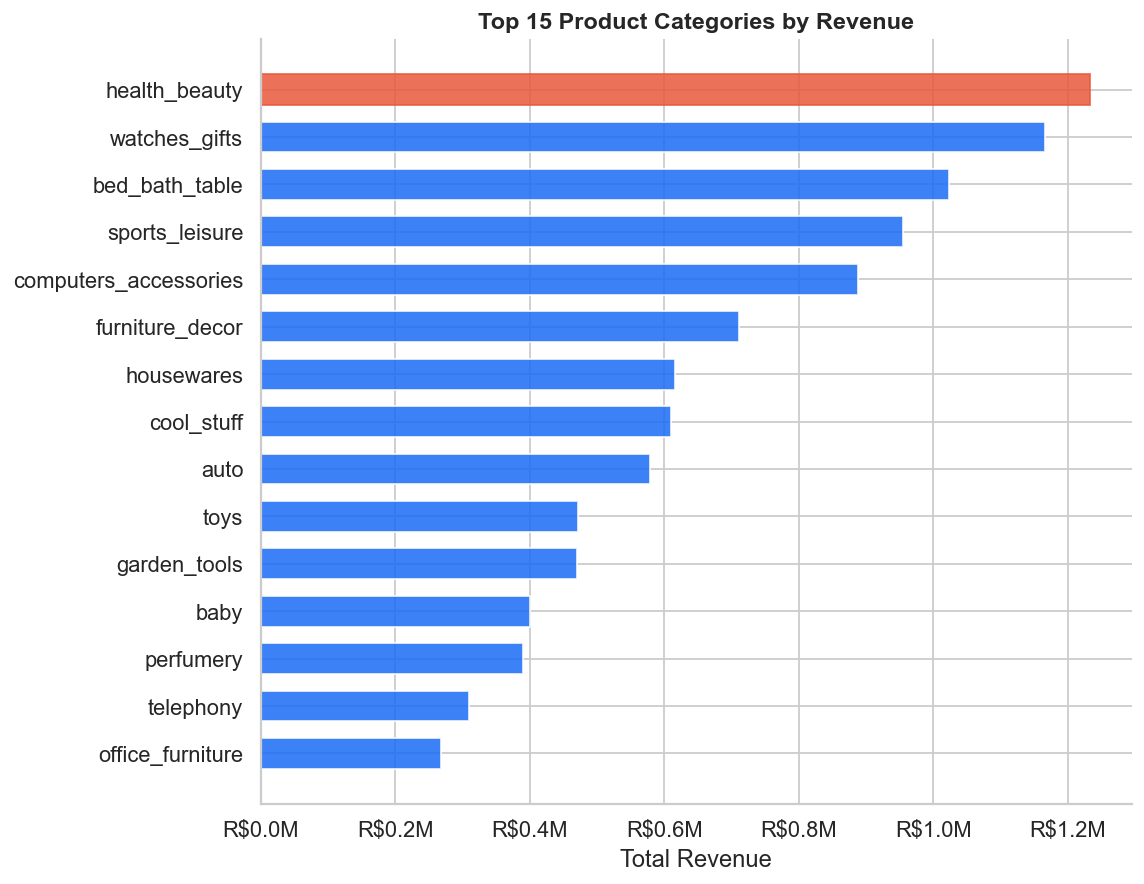

In [12]:
# ── 6.1  Top 15 categories by revenue ─────────────────────────────────────────
cat_rev = (
    master.groupby('category')['price']
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(cat_rev.index, cat_rev.values, color=ACCENT, alpha=0.85, height=0.65)
# Highlight top bar
bars[-1].set_color(WARM)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Top 15 Product Categories by Revenue')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig('fig_category_revenue.png', dpi=130, bbox_inches='tight')
plt.show()

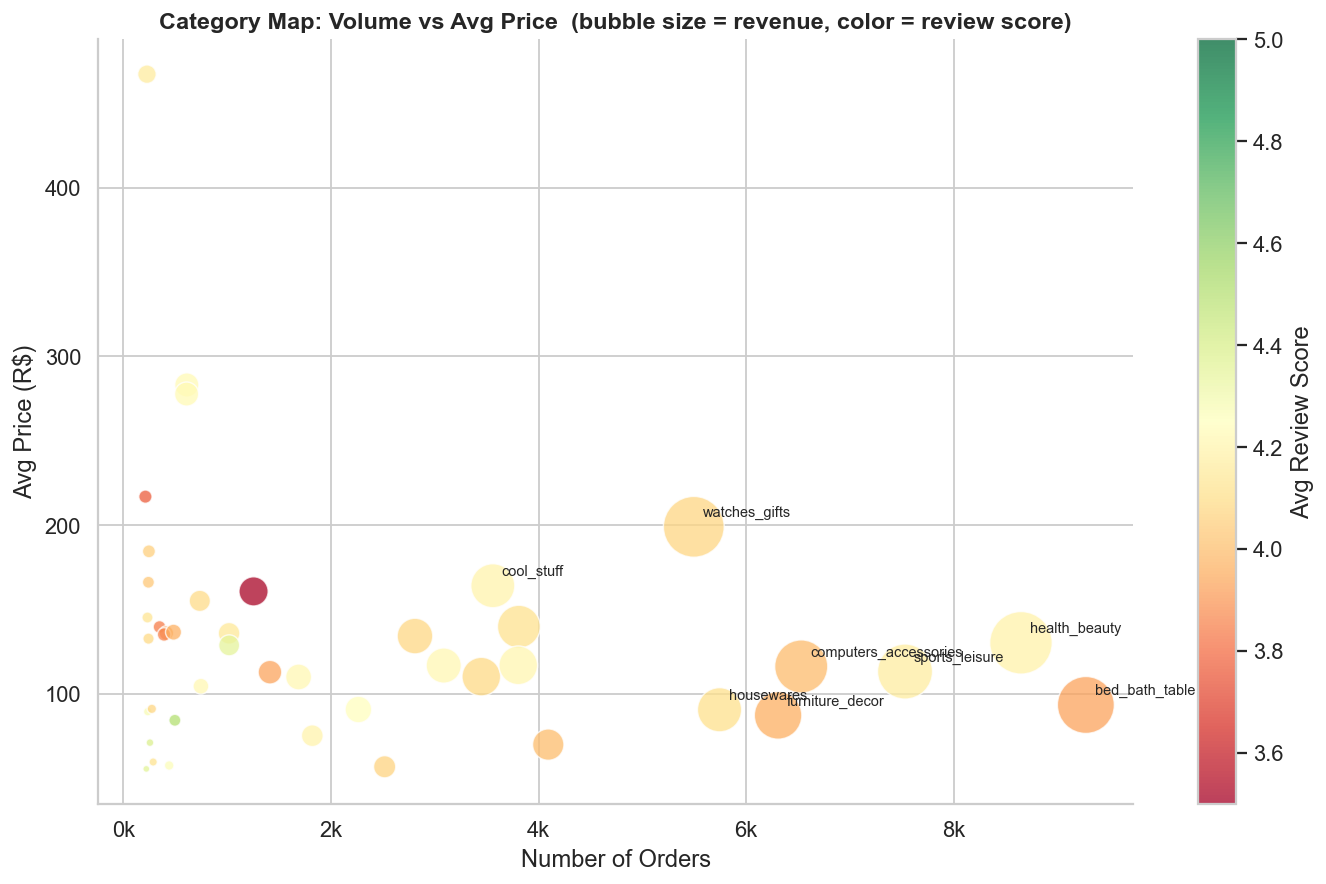


💡 Business insight: which categories have high volume but poor reviews? Those are service risk areas.


In [13]:
# ── 6.2  Category volume vs avg price (bubble chart) ──────────────────────────
cat_stats = master.groupby('category').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    avg_price=('price', 'mean'),
    avg_review=('review_score', 'mean')
).reset_index()

cat_stats = cat_stats[cat_stats['orders'] >= 200]   # filter noise

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    cat_stats['orders'], cat_stats['avg_price'],
    s=cat_stats['revenue'] / cat_stats['revenue'].max() * 1200,
    c=cat_stats['avg_review'], cmap='RdYlGn', alpha=0.75,
    edgecolors='white', linewidths=0.8, vmin=3.5, vmax=5.0
)
plt.colorbar(sc, ax=ax, label='Avg Review Score')

# Label top 8 categories by revenue
top8 = cat_stats.nlargest(8, 'revenue')
for _, row in top8.iterrows():
    ax.annotate(row['category'], (row['orders'], row['avg_price']),
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 4), textcoords='offset points')

ax.set_xlabel('Number of Orders')
ax.set_ylabel('Avg Price (R$)')
ax.set_title('Category Map: Volume vs Avg Price  (bubble size = revenue, color = review score)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_category_map.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 Business insight: which categories have high volume but poor reviews? Those are service risk areas.')

---
## 7. Customer Analysis

Repeat purchase rate: 3.0%

Order count distribution:
order_count
1    90557
2     2573
3      181
4       28
5        9
6        5
7        3
9        1


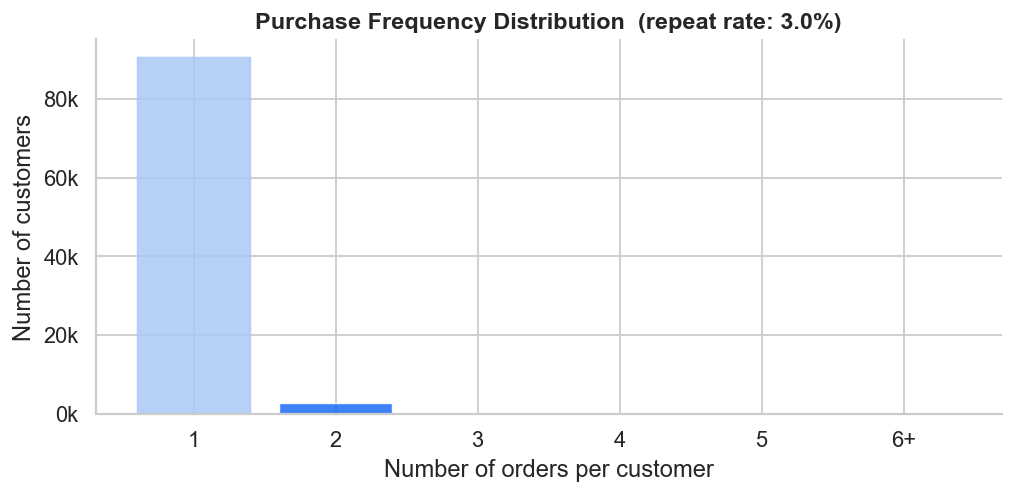

In [14]:
# ── 7.1  Repeat purchase rate ──────────────────────────────────────────────────
# One of the most important business metrics — what % of customers return?
purchase_counts = (
    master.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)

repeat_rate = (purchase_counts['order_count'] > 1).mean() * 100
print(f'Repeat purchase rate: {repeat_rate:.1f}%')
print('\nOrder count distribution:')
print(purchase_counts['order_count'].value_counts().head(8).to_string())

# ── 7.2  Plot purchase frequency distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
vc = purchase_counts['order_count'].clip(upper=6).value_counts().sort_index()
vc.index = [str(i) if i < 6 else '6+' for i in vc.index]
bars = ax.bar(vc.index, vc.values, color=ACCENT, alpha=0.85, edgecolor='white', linewidth=0.8)
bars[0].set_color('#aac8f7')   # 1-purchase customers dimmed
ax.set_xlabel('Number of orders per customer')
ax.set_ylabel('Number of customers')
ax.set_title(f'Purchase Frequency Distribution  (repeat rate: {repeat_rate:.1f}%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_purchase_frequency.png', dpi=130, bbox_inches='tight')
plt.show()

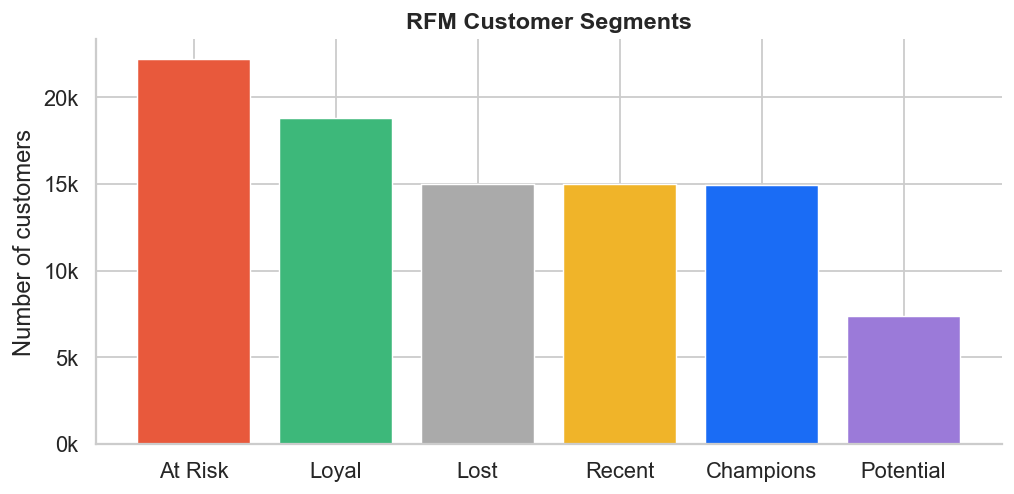

rfm.csv saved ✓

💡 Business insight: Champions + Loyal are retention targets. At Risk = re-engagement campaign.


In [15]:
# ── 7.3  RFM Segmentation ──────────────────────────────────────────────────────
# Recency-Frequency-Monetary: the classic framework for segmenting customers
snapshot_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = master.groupby('customer_unique_id').agg(
    recency  =('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary =('price', 'sum')
).reset_index()

# Score each dimension 1–5 (5 = best)
rfm['R'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['R'] + rfm['F'] + rfm['M']

# Segment labels
def rfm_segment(row):
    if row['R'] >= 4 and row['F'] >= 4: return 'Champions'
    elif row['R'] >= 3 and row['F'] >= 3: return 'Loyal'
    elif row['R'] >= 4 and row['F'] <= 2: return 'Recent'
    elif row['R'] <= 2 and row['F'] >= 3: return 'At Risk'
    elif row['R'] <= 2 and row['F'] <= 2: return 'Lost'
    else: return 'Potential'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_counts = rfm['segment'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
colors_map = {'Champions':'#1a6cf5','Loyal':'#3db87a','Recent':'#f0b429',
              'At Risk':'#e8593c','Lost':'#aaa','Potential':'#9b7ad9'}
ax.bar(seg_counts.index, seg_counts.values,
       color=[colors_map.get(s,'#ccc') for s in seg_counts.index],
       edgecolor='white', linewidth=0.8)
ax.set_title('RFM Customer Segments')
ax.set_ylabel('Number of customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_rfm_segments.png', dpi=130, bbox_inches='tight')
plt.show()

rfm.to_csv(os.path.join(DATA_DIR,'rfm.csv'), index=False)
print('rfm.csv saved ✓')
print('\n💡 Business insight: Champions + Loyal are retention targets. At Risk = re-engagement campaign.')

---
## 8. Delivery & Review Score Analysis

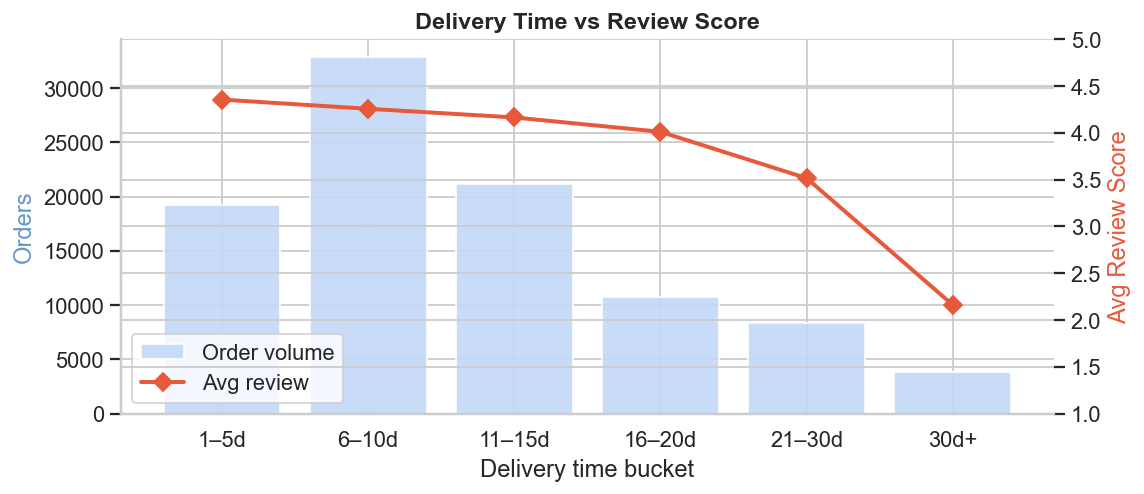


💡 If review score drops sharply after 10 days, delivery SLA of ≤10 days is a strategic KPI.


In [16]:
# ── 8.1  Delivery time vs review score ────────────────────────────────────────
# Hypothesis: late deliveries tank review scores
del_review = master[master['delivery_days'].between(1, 60)].copy()
del_review['delivery_bucket'] = pd.cut(
    del_review['delivery_days'],
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=['1–5d','6–10d','11–15d','16–20d','21–30d','30d+']
)

bucket_stats = del_review.groupby('delivery_bucket', observed=True).agg(
    avg_review=('review_score', 'mean'),
    orders=('order_id', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(bucket_stats['delivery_bucket'], bucket_stats['orders'],
        color='#c3d9f7', alpha=0.9, label='Order volume')
ax2.plot(bucket_stats['delivery_bucket'], bucket_stats['avg_review'],
         color=WARM, linewidth=2.2, marker='D', markersize=7, label='Avg review')

ax1.set_xlabel('Delivery time bucket')
ax1.set_ylabel('Orders', color='#6699cc')
ax2.set_ylabel('Avg Review Score', color=WARM)
ax2.set_ylim(1, 5)
ax1.set_title('Delivery Time vs Review Score')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.savefig('fig_delivery_vs_review.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 If review score drops sharply after 10 days, delivery SLA of ≤10 days is a strategic KPI.')

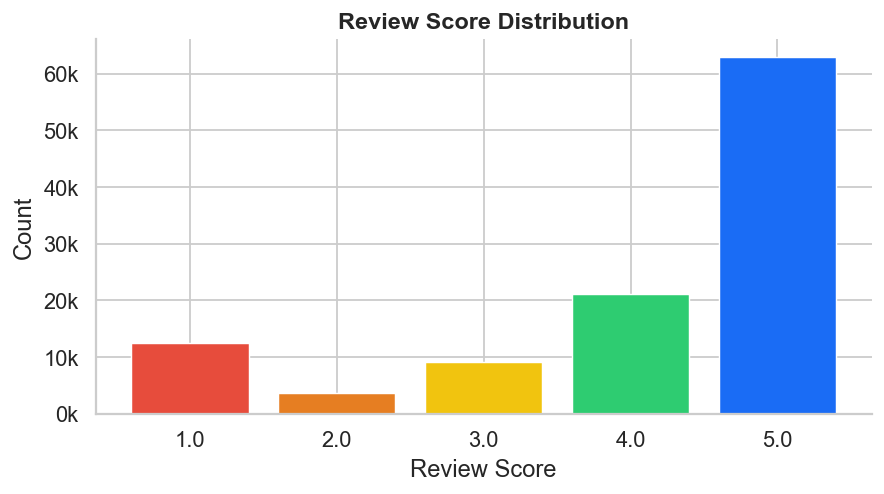

In [17]:
# ── 8.2  Review score distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
rev_counts = master['review_score'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1a6cf5']
ax.bar(rev_counts.index.astype(str), rev_counts.values,
       color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Review Score')
ax.set_ylabel('Count')
ax.set_title('Review Score Distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('fig_review_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9. Geographic Analysis

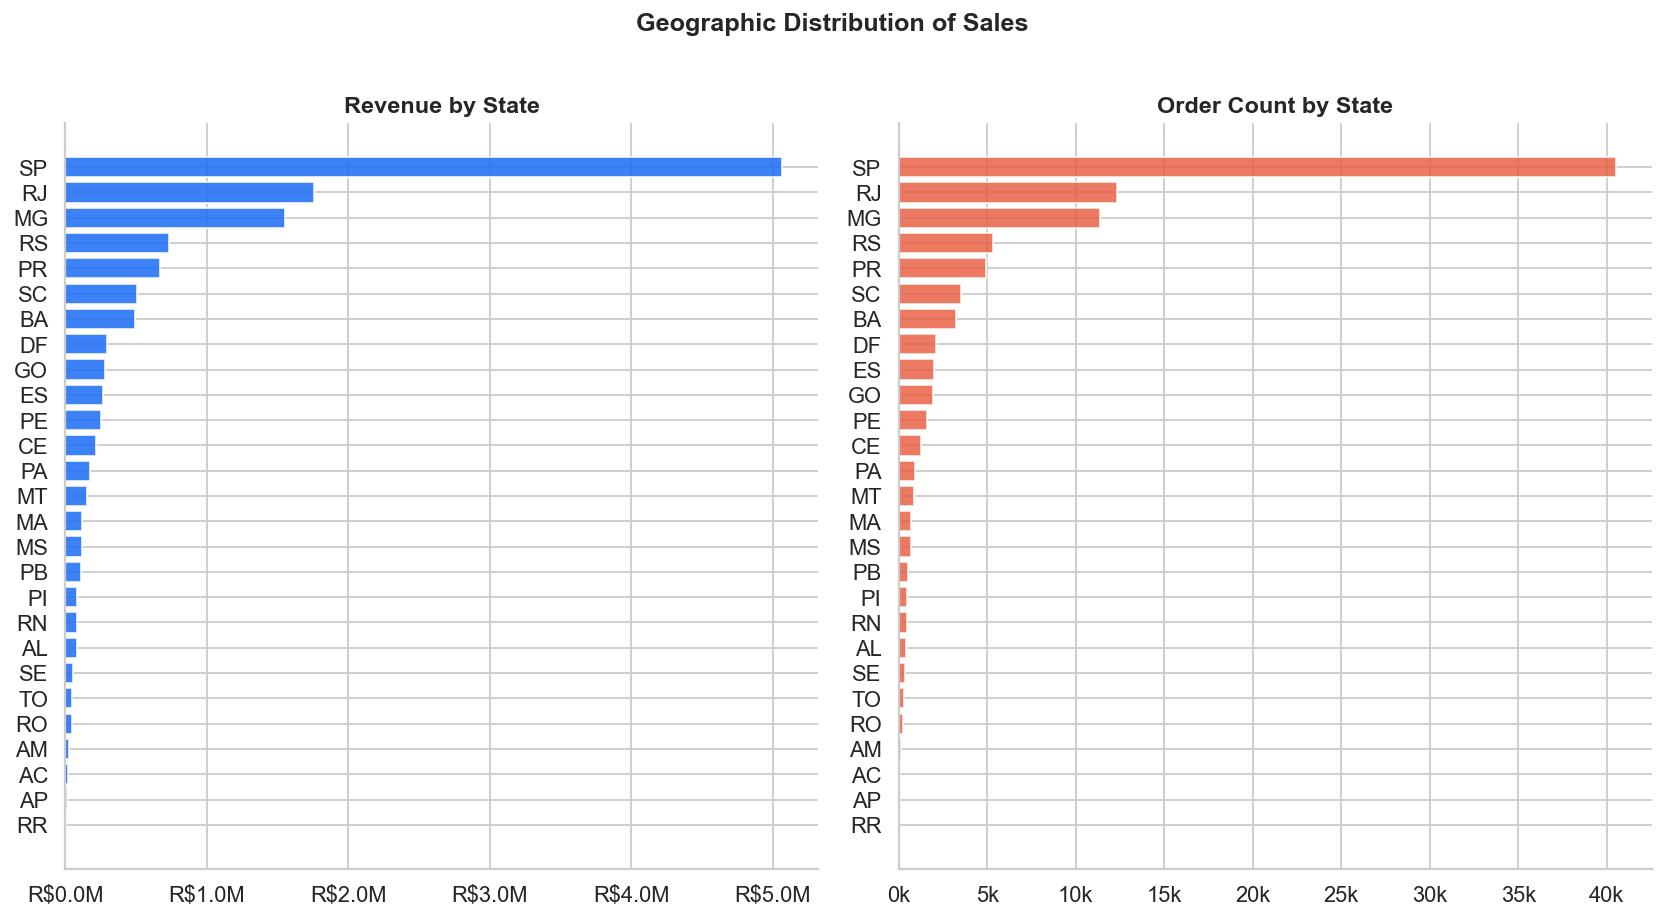


💡 SP dominates — high population but also best logistics. Underperforming states may be delivery-constrained.


In [18]:
# ── 9.1  Revenue by state ──────────────────────────────────────────────────────
state_rev = (
    master.groupby('customer_state')
    .agg(revenue=('price','sum'), orders=('order_id','nunique'))
    .reset_index()
    .sort_values('revenue', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

# Revenue
axes[0].barh(state_rev['customer_state'], state_rev['revenue'],
             color=ACCENT, alpha=0.85)
axes[0].set_title('Revenue by State')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Orders
state_rev_sorted2 = state_rev.sort_values('orders', ascending=True)
axes[1].barh(state_rev_sorted2['customer_state'], state_rev_sorted2['orders'],
             color=WARM, alpha=0.80)
axes[1].set_title('Order Count by State')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.suptitle('Geographic Distribution of Sales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_geo_revenue.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 SP dominates — high population but also best logistics. Underperforming states may be delivery-constrained.')

---
## 10. Time-of-Day & Day-of-Week Patterns

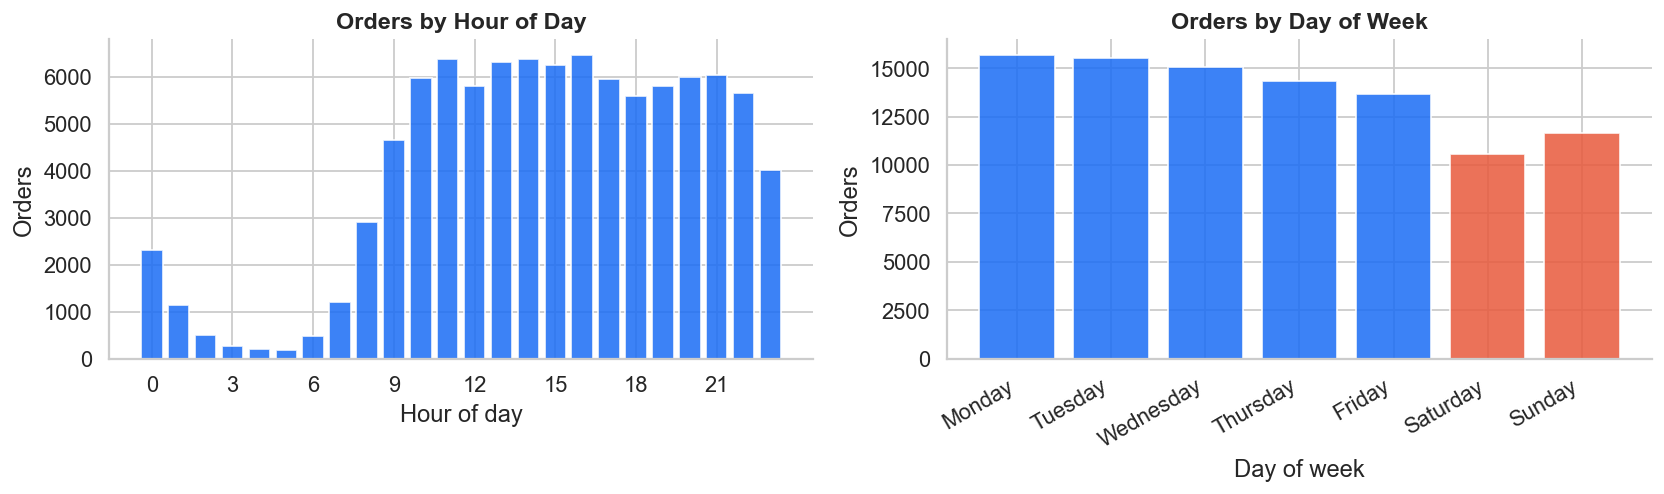

In [19]:
# ── 10.1  Orders by hour and weekday ──────────────────────────────────────────
# Why: useful for scheduling marketing campaigns and promotions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# By hour
hourly = master.groupby('hour')['order_id'].nunique()
axes[0].bar(hourly.index, hourly.values, color=ACCENT, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Orders')
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xticks(range(0, 24, 3))

# By weekday
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = master.groupby('weekday')['order_id'].nunique().reindex(day_order)
bar_colors = [WARM if d in ['Saturday','Sunday'] else ACCENT for d in day_order]
axes[1].bar(daily.index, daily.values, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Orders')
axes[1].set_title('Orders by Day of Week')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_time_patterns.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 11. Payment Analysis

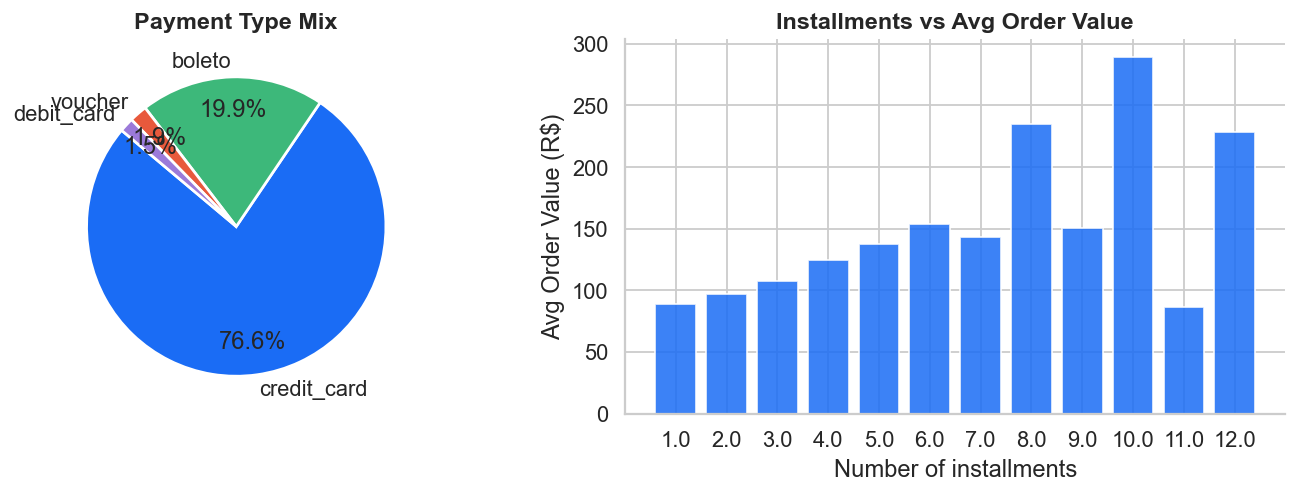


💡 If higher installments correlate with higher AOV, promoting installment plans could increase basket size.


In [20]:
# ── 11.1  Payment type breakdown ──────────────────────────────────────────────
pay_type = master.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(pay_type.values, labels=pay_type.index,
            colors=[ACCENT,'#3db87a',WARM,'#9b7ad9'],
            autopct='%1.1f%%', startangle=140,
            pctdistance=0.78, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Payment Type Mix')

# Installments: does more installments = higher order value?
installment_aov = (
    master[master['payment_installments'].between(1, 12)]
    .groupby('payment_installments')['price'].mean()
)
axes[1].bar(installment_aov.index.astype(str), installment_aov.values,
            color=ACCENT, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Number of installments')
axes[1].set_ylabel('Avg Order Value (R$)')
axes[1].set_title('Installments vs Avg Order Value')

plt.tight_layout()
plt.savefig('fig_payments.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 If higher installments correlate with higher AOV, promoting installment plans could increase basket size.')

---
## 12. EDA Summary & Next Steps

### Key Findings from EDA

Document your actual findings here after running the notebook:

| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | Revenue peaked in [month] | Seasonal promotions have outsized impact |
| 2 | Repeat purchase rate is ~X% | Retention is a growth lever — most customers only buy once |
| 3 | Review score drops after [X] delivery days | [X]-day delivery SLA is a strategic KPI |
| 4 | SP accounts for ~40% of revenue | Geographic expansion to [states] is a growth opportunity |
| 5 | Credit card dominates at ~75% | Payment diversity is low — opportunity for new methods |

### Next: Notebook 02 — ML Models
- `02_ml_churn.ipynb` — Predict repeat purchase using Random Forest
- `03_forecasting.ipynb` — Forecast next 6 months revenue with Prophet

### After that: Notebook 04 — Streamlit Dashboard
Tie everything together in an interactive app deployed to Streamlit Cloud.

In [21]:
# ── Final: print all saved artifacts ──────────────────────────────────────────
import glob
saved = glob.glob('../data/fig_*.png') + glob.glob('../data/*.csv')
print('Saved artifacts:')
for f in sorted(saved):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<45} {size_kb:>6.1f} KB')

Saved artifacts:
